# Examen Módulo 1 - Optimización.


## Primer punto. Optimización simbólica (3.4 puntos)

Dos postes,uno de 12 pies de altura y el otro de 28 pies, están a 30 pies de distancia. Se sostienen por dos cables conectados a una sola estaca desde el nivel del suelo hasta la parte superior de cada poste. ¿Donde debe colocarse la estaca para que se use la menor cantidad de cable?


In [475]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as opt
# import sympy as sym

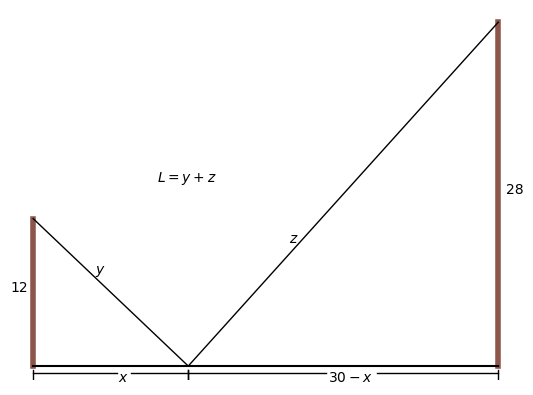

In [476]:
plt.plot([-10,-10],[0,12],'C5',lw=4)    # Poste izq
plt.plot([20,20],[0,28],'C5',lw=4)      # Poste der
plt.plot([-10,0,20],[12,0,28],'k',lw=1) # cable
plt.plot([-10,20],[0,0],'k')            # Suelo

# Acotaciones
plt.plot([-10,-10],[-2,-0.3],'k',lw=1)
plt.plot([0,0],[-2,-0.3],'k',lw=1)
plt.plot([-10,-4.6],[-0.6,-0.6],'k',lw=1)
plt.plot([-3.7,0],[-0.6,-0.6],'k',lw=1)

plt.plot([0,0],[-2,-0.3],'k',lw=1)
plt.plot([20,20],[-2,-0.3],'k',lw=1)
plt.plot([0,8.9],[-0.6,-0.6],'k',lw=1)
plt.plot([12.2,20],[-0.6,-0.6],'k',lw=1)


# Etiquetas
plt.text(-11.5,6,'12')
plt.text(20.5,14,'28')
plt.text(-2,15,'$L=y+z$')
plt.text(-6,7.5,'$y$')
plt.text(6.5,10,'$z$')
plt.text(-4.5,-1.3,'$x$')
plt.text(9,-1.3,'$30-x$')

plt.axis([-11,21,-1.1,29])
plt.axis('off')
plt.show()

1. Escriba la longitud $L$ del cable como una función de la distancia a la estaca desde el poste de 12 pies ($x$). Realice este punto usando fórmulas de $\LaTeX$, en celdas _Markdown_. (1.4 punto)
2. Determinar el valor de $x$ que minimiza la longitud del cable. (1 punto)
3. ¿Cuál es la distancia mínima del cable? (1 punto)


$ L = \sqrt{12^2 + x^2} + \sqrt{28^2 + (30-x)^2} $


In [477]:
def L(x):
    return np.sqrt(12**2 + x**2) + np.sqrt(28**2 + (30-x)**2)

solution = opt.minimize(L, -0)
print('La solución es x = ' + str(round(solution.x[0])) + ' y la longitud es ' + str(round(solution.fun)))

La solución es x = 9 y la longitud es 50


---


## Segundo punto. Programación lineal (3.4 puntos)

Una fábrica de confitería está interesada en mezclar tres de sus marcas principales de golosinas (M1, M2, M3) para obtener tres nuevos productos (P1, P2, P3), que desea vender al precio de 4,3,2 u.m. por caja, respectivamente.
La empresa puede importar 2000 cajas de M1, 4000 de la M2 y 1000 de la M3, siendo el precio que debe pagar de 3,2 y 1 u.m. por cada tipo de caja.

El proveedor solicita que el Producto 1 (P1) contenga como mínimo el 80% de M1 y como máximo el 20% de M3. El producto 2 (P2) deberá contener como mínimo el 20% de M1 y no más del 80% de M3. El producto 3 (P3) no podrá contener más del 70% de M3.

Encuentre la combinación que le genere el **máximo** beneficio (precio de venta menos el costo).

Use las variables $x_{ij}$: Como la cantidad de la marca $i$ en el producto $j$.

1. Escriba la función objetivo a **minimizar** junto con las restricciones, explicando detalladamente cada paso (usando fórmulas de $\LaTeX$, en celdas Markdown). Además escriba el problema en la forma
   \begin{equation}
   \begin{array}{ll}
   \min*{\boldsymbol{x}} & \boldsymbol{c}^T\boldsymbol{x} \\
   \text{s. a. } & \boldsymbol{A}*{eq}\boldsymbol{x}=\boldsymbol{b}\_{eq} \\
   & \boldsymbol{A}\boldsymbol{x}\leq\boldsymbol{b},
   \end{array}\qquad\text{(2.3 puntos)}
   \end{equation}
2. Resuelva el problema utilizando la función `linprog`. ¿Cuál es la combinación óptima para cada producto?, ¿Cuál es el beneficio que se genera? (1.1 puntos)


Se plantea la ecuación $ ganancias - gasto $

\begin{equation}
\begin{array}{ll}

\min*{x} & 4\*(x*{11} + x*{21} + x*{31}) + 3*(x*{12} + x*{22} + x\_{32}) + 2*(x*{13} + x*{23} + x*{33}) \\
& - (3\*(x*{11} + x*{12} + x*{13}) + 2\*(x*{21} + x*{22} + x*{23}) + (x*{31} + x*{32} + x*{33})) \\

\end{array}
\end{equation}


Se simplifica y se consideran las restricciones

\begin{equation}
\begin{array}{ll}

\min*{x} & x*{11} - x*{13} + 2x*{21} + x*{22} + 3x*{31} +2x*{32} + x*{33} \\

\text{s. a.} & x*{11} + x*{12} + x*{13} \leq 2000 \\
& x*{21} + x*{22} + x*{23} \leq 4000 \\
& x*{31} + x*{32} + x*{33} \leq 1000 \\
& x*{11} \geq 0.8(x*{11} + x*{21} + x*{31}) \\
& x*{31} \leq 0.2(x*{11} + x*{21} + x*{31}) \\
& x*{12} \geq 0.2(x*{12} + x*{22} + x*{32}) \\
& x*{32} \leq 0.8(x*{12} + x*{22} + x*{32}) \\
& x*{33} \leq 0.7(x*{13} + x*{23} + x\_{33}) \\
\end{array}
\end{equation}


In [478]:
c=np.array([1,0,-1,2,1,0,3,2,1])
A=np.array([
    [1,1,1,0,0,0,0,0,0],
    [0,0,0,1,1,1,0,0,0],
    [0,0,0,0,0,0,1,1,1]
    ])
b=np.array([2000,4000,1000])

opt.linprog(c,A,b)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -2000.0
              x: [ 0.000e+00  0.000e+00  2.000e+03  0.000e+00  0.000e+00
                   0.000e+00  0.000e+00  0.000e+00  0.000e+00]
            nit: 0
          lower:  residual: [ 0.000e+00  0.000e+00  2.000e+03  0.000e+00
                              0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00]
                 marginals: [ 2.000e+00  1.000e+00  0.000e+00  2.000e+00
                              1.000e+00  0.000e+00  3.000e+00  2.000e+00
                              1.000e+00]
          upper:  residual: [       inf        inf        inf        inf
                                    inf        inf        inf        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00
                              0.000e+00  0.000e+00  0.000e+00  0

---


## Tercer punto. Ajuste de curvas (3.4 puntos)

Los siguientes datos extraidos de _Administrative Office of the U.S. Courts_, representan el número de bancarrotas en miles entre los años 1980 y 2022.

https://abi-org.s3.amazonaws.com/Newsroom/Bankruptcy_Statistics/Total-Business-Consumer1980-Present.pdf


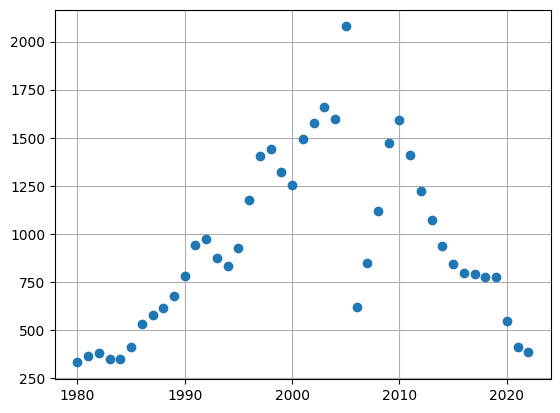

In [482]:
df=pd.DataFrame()

df['periodo']=range(0,43)
df['declaraciones'] = np.array([331.264,363.943,380.251,348.880,348.521,412.510,530.438,577.999,613.465,679.461,782.960,943.987,971.517,875.202,832.829,926.601,1178.555,1404.145,1442.549,1319.465,1253.444,1492.129,1577.651,1660.245,1597.462,2078.415,617.660,850.912,1117.771,1473.675,1593.081,1410.653,1221.091,1071.932,936.795,844.495,794.960,789.020,773.418,774.940,544.463,413.616,387.721])
plt.plot(df['periodo']+1980,df['declaraciones'],'o')
plt.grid()

1. Ajuste los salarios con polinomios de grado 1 a 5 y muestre los errores de forma gráfica, ¿Qué polinómio se ajusta mejor? (2.1 puntos)
2. Muestre en un gráfico los datos y el polinómio que mejor se ajuste (0.6 puntos)
3. Usar el modelo para averiguar el número de bancarrotas a mediados de 1995 y predecirlo para el año 2023. ¿Qué diferencias encuentra en cuanto a la interpolación y la extrapolación? (0.6 puntos)


1. El polinomio que mejor se ajusta es el de grado 5


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 7602668.271760222
        x: [-1.888e+04  9.906e+00]
      nit: 7
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[ 1.163e-02 -5.994e-09]
            [-5.994e-09  2.998e-12]]
     nfev: 102
     njev: 34
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 7619705.448102966
        x: [-1.020e+04  2.731e-01  2.646e-03]
      nit: 10
      jac: [ 1.205e+02  2.539e+05  5.477e+08]
 hess_inv: [[ 1.089e+04 -1.009e+01  2.325e-03]
            [-1.009e+01  9.371e-03 -2.162e-06]
            [ 2.325e-03 -2.162e-06  4.998e-10]]
     nfev: 240
     njev: 57
  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 618609213.6259333
        x: [ 9.653e-01  3.153e-01  1.474e-01 -7.363e-05]
      nit: 1
      jac: [ 1.056e+03 -1.912e+06 -1.187e+10  1.275e+12]
 hess_inv: [[ 1.000e+00 -3.774e-17 -7.55

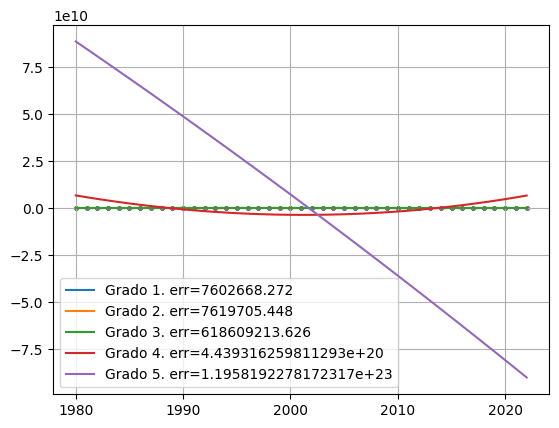

[[                1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1                 1
                  1                 1                 1]
 [             1980              1981              1982              1983
               1984              1985              1986              1987
               1988              1989              1990

In [487]:
x=np.array(df['periodo'] + 1980)
y=np.array(df['declaraciones'])

def criterio_opt(beta,x,y):
  n=len(beta)
  X=np.array([x**i for i in range(n)])
  f=np.dot(beta,X)
  return np.sum((y-f)**2)

for n in range(2,7):
    beta0=np.random.rand(n)
    
    solution=opt.minimize(criterio_opt,beta0,args=(x,y))

    X = np.array([x**i for i in range(n)])

    f = np.dot(solution.x, X)
    print(solution)
    plt.scatter(x,y,s=5)
    plt.plot(x,f,label="Grado "+str(n-1)+". err="+str(round(solution.fun,3)))
plt.legend()
plt.grid()
plt.show()
print(X)
print(x)
print(y)
print(np.dot(solution.x, X))

# def ridge(beta,x,y,lmbd):
#   n=len(beta)
#   X=np.array([x**i for i in range(n)])
#   f=np.dot(beta,X)                     # Mismo modelo
#   return np.sum((y-f)**2)+lmbd*(beta**2).sum()

# sol=[]
# lmbd=50
# plt.scatter(x,y,c='k',s=5)
# for n in range(2,7):
#   beta0=np.random.rand(n)
#   sol.append(opt.minimize(ridge,beta0,args=(x,y,lmbd)))

#   X=np.array([x**i for i in range(n)])
#   f=np.dot(sol[-1].x,X)                # sol[-1]  ->  última solución almacenada
#   plt.plot(x,f,label='Grado '+str(n-1))
# plt.legend()
# plt.grid()
# plt.show()

# def lasso(beta,x,y,lmbd):
#   n=len(beta)
#   X=np.array([x**i for i in range(n)])
#   f=np.dot(beta,X)                     # Mismo modelo
#   return np.sum((y-f)**2)+lmbd*(np.abs(beta)).sum()

# sol=[]
# lmbd=50
# plt.scatter(x,y,c='k',s=5)
# for n in range(2,7):
#   beta0=np.random.rand(n)
#   sol.append(opt.minimize(lasso,beta0,args=(x,y,lmbd)))

#   X=np.array([x**i for i in range(n)])
#   f=np.dot(sol[-1].x,X)                # sol[-1]  ->  última solución almacenada
#   plt.plot(x,f,label='Grado '+str(n-1))
# plt.legend()
# plt.grid()

# # Errores
# plt.figure()
# for n,err in enumerate(sol):
#   plt.plot(n+1,err.fun,'o',ms=10)
# plt.grid()
# plt.show()